In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine


In [33]:
data=load_wine(as_frame=True)

In [34]:
df=data.frame

In [35]:
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [36]:
X=df.drop("target",axis=1)

In [37]:
y=df["target"]

In [38]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_scaled=sc.fit_transform(X)

In [39]:
from sklearn.manifold import MDS
mds = MDS(
    n_components=2,
    random_state=42,
    n_init=13,
    max_iter=300
)

X_mds = mds.fit_transform(X_scaled)

In [40]:
X_mds

array([[ 0.1564313 , -4.19003822],
       [ 1.71940817, -2.67404923],
       [-0.49636581, -3.15946221],
       [-1.27946408, -4.93579382],
       [-1.51867358, -1.28927006],
       [-1.16919652, -3.97319189],
       [-0.15009957, -3.19804366],
       [-1.71236163, -2.66769125],
       [ 0.70481968, -3.4372858 ],
       [ 0.56171503, -3.15140472],
       [-0.29182431, -4.22336804],
       [-0.24239319, -2.08538738],
       [-0.03777415, -2.43359826],
       [ 0.88689318, -5.12186626],
       [-0.25953713, -5.61555149],
       [-1.59758889, -2.9935376 ],
       [-2.00798202, -2.9798821 ],
       [-1.64209573, -2.41352617],
       [-1.70307945, -4.75096199],
       [-0.24174371, -2.6900364 ],
       [ 1.04534333, -3.74212084],
       [-0.34494759, -1.06297129],
       [ 0.96080742, -2.5030682 ],
       [ 0.83453049, -1.41153346],
       [ 0.73248303, -1.60820873],
       [-3.60569372, -2.35491622],
       [-0.44213643, -1.97251119],
       [ 0.3395371 , -1.24466766],
       [-1.07666286,

In [41]:
target_names=data.target_names

In [42]:
def plot_2d(Z, y, title):
    plt.figure(figsize=(6, 5))
    for label in np.unique(y):
        plt.scatter(
            Z[y == label, 0],
            Z[y == label, 1],
            label=target_names[label],
            s=45
        )
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.title(title)
    plt.legend()
    plt.show()

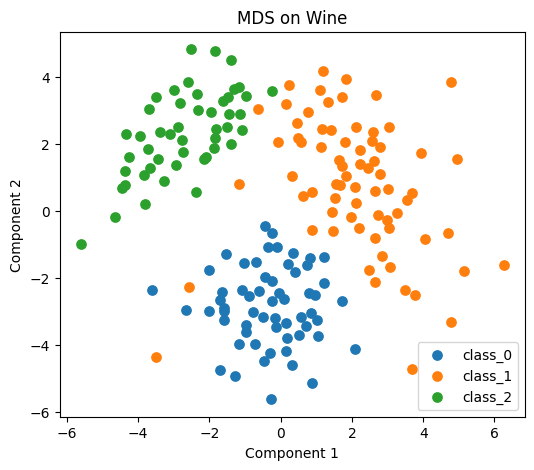

In [43]:
plot_2d(X_mds, y, "MDS on Wine")

In [44]:
print("stress_ =", mds.stress_)

stress_ = 21371.758499353156


In [45]:
import numpy as np
from sklearn.metrics import pairwise_distances

D = pairwise_distances(X)              # original distances
D_hat = pairwise_distances(X_mds)      # embedded distances

normalized_stress = np.sqrt(mds.stress_ / (D**2).sum())

print("Normalized stress =", normalized_stress)

Normalized stress = 0.001847284828551716


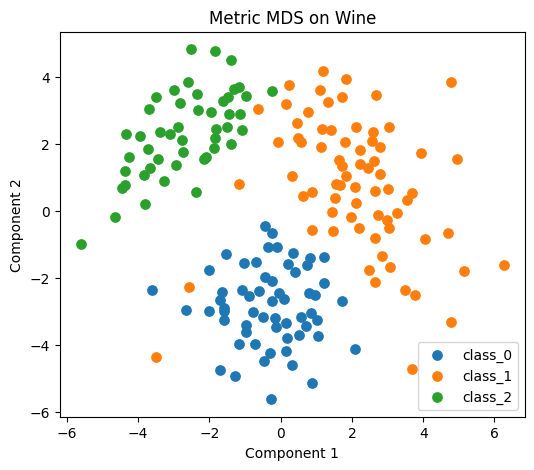

Metric MDS stress_: 21371.758499353156


In [46]:
mds_metric = MDS(
    n_components=2,
    metric=True,
    random_state=42,
    n_init=13
)

Z_metric = mds_metric.fit_transform(X_scaled)
plot_2d(Z_metric, y, "Metric MDS on Wine")
print("Metric MDS stress_:", mds_metric.stress_)